# Step 1 — Data Understanding & Preprocessing
**Project:** AI Mobile App for Early Identification of Student Mental Health via Behavior & Speech
**Part:** Time-series forecasting component (Naive / ARIMA / LSTM), 3-month-ahead forecast

This notebook covers the **first coding milestone**:
1. Load the raw multi-student dataset
2. Clean it (there is a corrupted duplicate header row baked into the CSV — we fix that here)
3. Explore it (EDA) so we understand what we're forecasting
4. Encode the categorical targets (`Stress_Level`, `Mental_Health_Status`) into ordered numeric scores, matching the thesis (2.1.2 Data Preprocessing and Feature Engineering)
5. Save a clean, analysis-ready file that the next notebook (model training: Naive → ARIMA → LSTM) will load

> Run every cell top to bottom. Each cell is self-contained and explained above it.


## 1. Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 4)


## 2. Load the raw CSV
Put the CSV in the same folder as this notebook (or change the path below).

In [14]:
DATA_PATH = "../data/raw/student_data.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (38651, 15)


,StudentID,Profile,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,Stress_Level,Mental_Health_Status
0,1,High_Achiever,1/1/2015,74.9,116.9,74.2,15.4,7.24,7019,Neutral,6,4.8,0,Medium,Normal
1,1,High_Achiever,1/2/2015,69.8,120.2,74,14.7,6.16,5411,Sad,5,6.59,0,Medium,Mild Stress
2,1,High_Achiever,1/3/2015,69.5,113.7,75.3,15.6,7.33,5627,Happy,5,4.67,1,Medium,Depression
3,1,High_Achiever,1/4/2015,70.8,114.6,79.4,15.2,7.22,5051,Happy,6,6.19,0,Medium,Depression
4,1,High_Achiever,1/5/2015,70.2,117.1,75.5,15.2,7.1,8066,Neutral,5,5.76,2,Medium,Depression


## 3. Clean the data

Two issues were found when inspecting this file:

1. **A stray duplicate header row** is embedded inside the data (a row where `StudentID == "StudentID"`). This happens when multiple CSV exports get concatenated. It also forces every column to be read as text (`object`) instead of numbers.
2. **Correct data types** — dates need to become real `datetime`, and numeric columns need to become `float`/`int` instead of text.

We fix both below.

In [15]:
df = df_raw.copy()

# 3.1 Drop the stray header row wherever it appears
before = len(df)
df = df[df['StudentID'] != 'StudentID'].copy()
print(f"Dropped {before - len(df)} corrupted row(s)")

# 3.2 Correct data types
df['StudentID'] = df['StudentID'].astype(int)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

numeric_cols = [
    'Heart_Rate', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
    'Respiration_Rate', 'Sleep_Duration', 'Activity_Levels',
    'Cognitive_Load', 'Study_Hours', 'Academic_Stressors'
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.sort_values(['StudentID', 'Timestamp']).reset_index(drop=True)

print("Clean shape:", df.shape)
df.dtypes


Dropped 1 corrupted row(s)
Clean shape: (38650, 15)


StudentID                            int32
Profile                                str
Timestamp                   datetime64[us]
Heart_Rate                         float64
Blood_Pressure_Systolic            float64
Blood_Pressure_Diastolic           float64
Respiration_Rate                   float64
Sleep_Duration                     float64
Activity_Levels                      int64
Mood                                   str
Cognitive_Load                       int64
Study_Hours                        float64
Academic_Stressors                   int64
Stress_Level                           str
Mental_Health_Status                   str
dtype: object

## 4. Sanity checks

- Any missing values after coercion?
- Is every student's series continuous daily data (no big gaps)?
- How many students / what date range?

In [16]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Students:", sorted(df['StudentID'].unique()))
print()
print(df.groupby('StudentID')['Timestamp'].agg(start='min', end='max', n_rows='count'))


Missing values per column:
StudentID                   0
Profile                     0
Timestamp                   0
Heart_Rate                  0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Respiration_Rate            0
Sleep_Duration              0
Activity_Levels             0
Mood                        0
Cognitive_Load              0
Study_Hours                 0
Academic_Stressors          0
Stress_Level                0
Mental_Health_Status        0
dtype: int64

Students: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

               start        end  n_rows
StudentID                              
1         2015-01-01 2025-07-31    3865
2         2015-01-01 2025-07-31    3865
3         2015-01-01 2025-07-31    3865
4         2015-01-01 2025-07-31    3865
5         2015-01-01 2025-07-31    3865
6         2015-01-01 2025-07-31    3865
7         2015-01-01 2025-07-31    3865
8         2015-01-01 2025-07-31    3865
9         2015-01-01 2025-07-31    3865
10        2015-01-01 2025-

In [17]:
# If the coercion above created any NaNs (bad values that weren't numbers), inspect them here
bad_rows = df[df[numeric_cols].isna().any(axis=1)]
print(f"{len(bad_rows)} rows with unparseable numeric values")
bad_rows.head()


0 rows with unparseable numeric values


,StudentID,Profile,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,Stress_Level,Mental_Health_Status


In [18]:
# Drop any unparseable rows (should be 0 for this dataset, but keep the guard for real-world use)
df = df.dropna(subset=numeric_cols).reset_index(drop=True)
print("Final clean shape:", df.shape)


Final clean shape: (38650, 15)


## 5. Meet the data: student profiles

Each `StudentID` represents one synthetic student with a behavioral **Profile** (e.g. `Burnout_Prone`, `Highly_Anxious`, `Calm`). This matters for later modeling — we will forecast **per student**, since each profile has a different baseline and trend.

In [19]:
profile_map = df.drop_duplicates('StudentID')[['StudentID', 'Profile']].sort_values('StudentID')
profile_map


,StudentID,Profile
0,1,High_Achiever
3865,2,Night_Owl
7730,3,Calm
11595,4,Burnout_Prone
15460,5,Athlete
19325,6,Highly_Anxious
23190,7,Depression_Prone
27055,8,Balanced
30920,9,Overworked
34785,10,Irregular


## 6. Target variables

The thesis defines two categorical outputs to forecast:
- **Stress_Level**: Low / Medium / High
- **Mental_Health_Status**: Normal / Mild Stress / Moderate Stress / Severe Stress / Anxiety / Depression

Both are **ordinal** (there's a natural order of severity), so we encode them as ordered integers rather than one-hot — this lets us treat them as a numeric score for time-series regression (ARIMA/LSTM predict a number, which we then map back to a category), exactly as described in the thesis (2.1.5 — numeric predictions transformed into interpretable categories).

In [20]:
stress_order = ['Low', 'Medium', 'High']
mh_order = ['Normal', 'Mild Stress', 'Moderate Stress', 'Severe Stress', 'Anxiety', 'Depression']

print("Stress_Level categories found:", df['Stress_Level'].unique())
print("Mental_Health_Status categories found:", df['Mental_Health_Status'].unique())

df['Stress_Level_Score'] = df['Stress_Level'].map({v: i for i, v in enumerate(stress_order)})
df['Mental_Health_Status_Score'] = df['Mental_Health_Status'].map({v: i for i, v in enumerate(mh_order)})

df[['Stress_Level', 'Stress_Level_Score', 'Mental_Health_Status', 'Mental_Health_Status_Score']].head()


Stress_Level categories found: <StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
Mental_Health_Status categories found: <StringArray>
[         'Normal',     'Mild Stress',      'Depression',         'Anxiety',
 'Moderate Stress',   'Severe Stress']
Length: 6, dtype: str


,Stress_Level,Stress_Level_Score,Mental_Health_Status,Mental_Health_Status_Score
0,Medium,1,Normal,0
1,Medium,1,Mild Stress,1
2,Medium,1,Depression,5
3,Medium,1,Depression,5
4,Medium,1,Depression,5


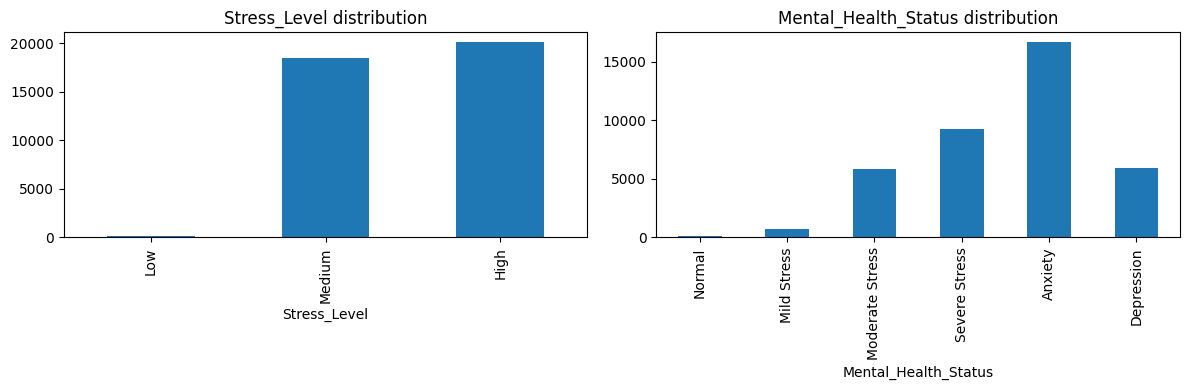

In [21]:
# Class balance — good to know before modeling (imbalance affects RMSE interpretation later)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Stress_Level'].value_counts().reindex(stress_order).plot(kind='bar', ax=axes[0], title='Stress_Level distribution')
df['Mental_Health_Status'].value_counts().reindex(mh_order).plot(kind='bar', ax=axes[1], title='Mental_Health_Status distribution')
plt.tight_layout()
plt.show()


## 7. Visualize one student's time series

This is the same kind of plot as Figure 7 in the thesis (Stress level score over the years) — we look at one student first to sanity-check trend/seasonality before forecasting.

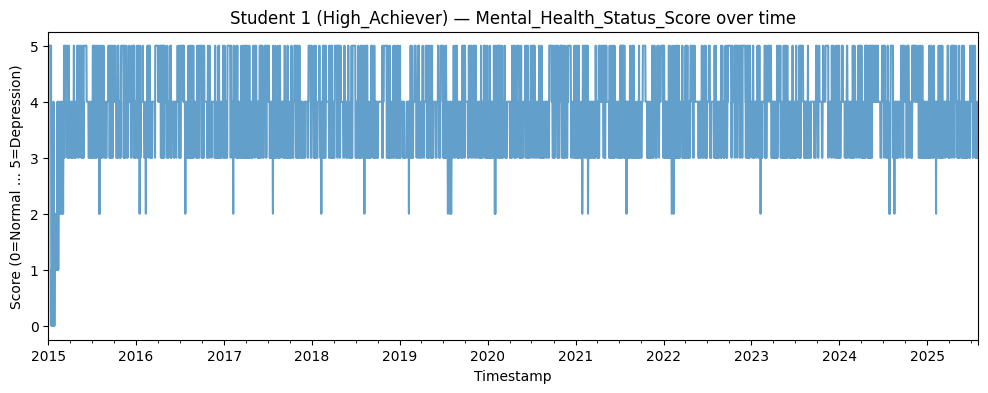

In [22]:
sid = 1
s = df[df['StudentID'] == sid].set_index('Timestamp')

fig, ax = plt.subplots(figsize=(12, 4))
s['Mental_Health_Status_Score'].plot(ax=ax, alpha=0.7)
ax.set_title(f"Student {sid} ({profile_map.set_index('StudentID').loc[sid, 'Profile']}) — Mental_Health_Status_Score over time")
ax.set_ylabel("Score (0=Normal ... 5=Depression)")
plt.show()


## 8. Correlation check

Quick look at which behavioral/physiological features move together with the mental health score — this justifies which features go into the forecasting models.

In [23]:
corr_cols = numeric_cols + ['Stress_Level_Score', 'Mental_Health_Status_Score']
corr = df[corr_cols].corr()
corr[['Stress_Level_Score', 'Mental_Health_Status_Score']].sort_values('Mental_Health_Status_Score', ascending=False)


,Stress_Level_Score,Mental_Health_Status_Score
Mental_Health_Status_Score,0.337860,1.000000
Stress_Level_Score,1.000000,0.337860
Study_Hours,0.654183,0.300984
Academic_Stressors,0.776859,0.293665
Cognitive_Load,0.701112,0.263170
Blood_Pressure_Systolic,0.186478,0.069535
Blood_Pressure_Diastolic,0.128227,0.038538
Heart_Rate,0.135196,0.007720
Respiration_Rate,0.009403,-0.002583
Activity_Levels,-0.246725,-0.205069


## 9. Save the cleaned dataset

We save this to `student_data_clean.csv`. The **next notebook** (Step 2: model training — Naive, ARIMA, LSTM, 3-month/90-day-ahead forecast) will load this file directly, so you don't need to repeat this cleaning step.

In [24]:
OUT_PATH = "../data/processed/student_data_clean.csv"
df.to_csv(OUT_PATH, index=False)
print(f"Saved {df.shape[0]} rows x {df.shape[1]} cols to {OUT_PATH}")
df.head()


Saved 38650 rows x 17 cols to ../data/processed/student_data_clean.csv


,StudentID,Profile,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,Stress_Level,Mental_Health_Status,Stress_Level_Score,Mental_Health_Status_Score
0,1,High_Achiever,2015-01-01,74.9,116.9,74.2,15.4,7.24,7019,Neutral,6,4.80,0,Medium,Normal,1,0
1,1,High_Achiever,2015-01-02,69.8,120.2,74.0,14.7,6.16,5411,Sad,5,6.59,0,Medium,Mild Stress,1,1
2,1,High_Achiever,2015-01-03,69.5,113.7,75.3,15.6,7.33,5627,Happy,5,4.67,1,Medium,Depression,1,5
3,1,High_Achiever,2015-01-04,70.8,114.6,79.4,15.2,7.22,5051,Happy,6,6.19,0,Medium,Depression,1,5
4,1,High_Achiever,2015-01-05,70.2,117.1,75.5,15.2,7.10,8066,Neutral,5,5.76,2,Medium,Depression,1,5


## What's next (Step 2)

Once you're happy with this cleaning/EDA step, the next notebook will:
1. Build **per-student** time-series (one series per `StudentID`)
2. Create a proper **train/test split for forecasting** (train on history, hold out the **last 90 days ≈ 3 months** per student — this matches the thesis's 3-month forecast horizon)
3. Implement and compare **Naive**, **ARIMA**, and **LSTM** models
4. Evaluate with **RMSE** (and MAE) exactly as in the thesis, and reproduce the RMSE comparison chart and actual-vs-predicted plots

Let me know when you're ready and we'll build that notebook next.
